# Module 1: Statistical Analysis & Baseline Models

**Objectives:**
1. Perform Exploratory Data Analysis (EDA) on the cleaned traffic dataset.
2. Discover traffic trends (Peak hours, Weekly behavior, Variance over time).
3. Perform Correlation Analysis.
4. Implement Linear Regression entirely from scratch using mathematical foundations.
5. Compare the custom model against a standard baseline (Scikit-Learn).
6. Analyze the Bias-Variance tradeoff.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set plot style 
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the cleaned data 
df = pd.read_csv("data/processed/cleaned_traffic.csv")

# Convert DateTime back to proper datetime object after loading from CSV
df['DateTime'] = pd.to_datetime(df['DateTime'])

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (48120, 10)


,DateTime,Junction,Vehicles,Hour,Day,DayOfWeek,Month,Year,Is_Weekend,Is_Peak_Hour
0,2015-11-01 00:00:00,1,15,0,1,6,11,2015,1,0
1,2015-11-01 01:00:00,1,13,1,1,6,11,2015,1,0
2,2015-11-01 02:00:00,1,10,2,1,6,11,2015,1,0
3,2015-11-01 03:00:00,1,7,3,1,6,11,2015,1,0
4,2015-11-01 04:00:00,1,9,4,1,6,11,2015,1,0


## 1. Statistical Analysis & Traffic Trend Discovery
We need to mathematically and visually prove the traffic trends. We will look at Variance across time, Mean patterns by day, and Peak hour detection.

C:\Users\Dell\AppData\Local\Temp\ipykernel_17440\1867528824.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_traffic = df.set_index('DateTime').resample('M')['Vehicles'].mean()


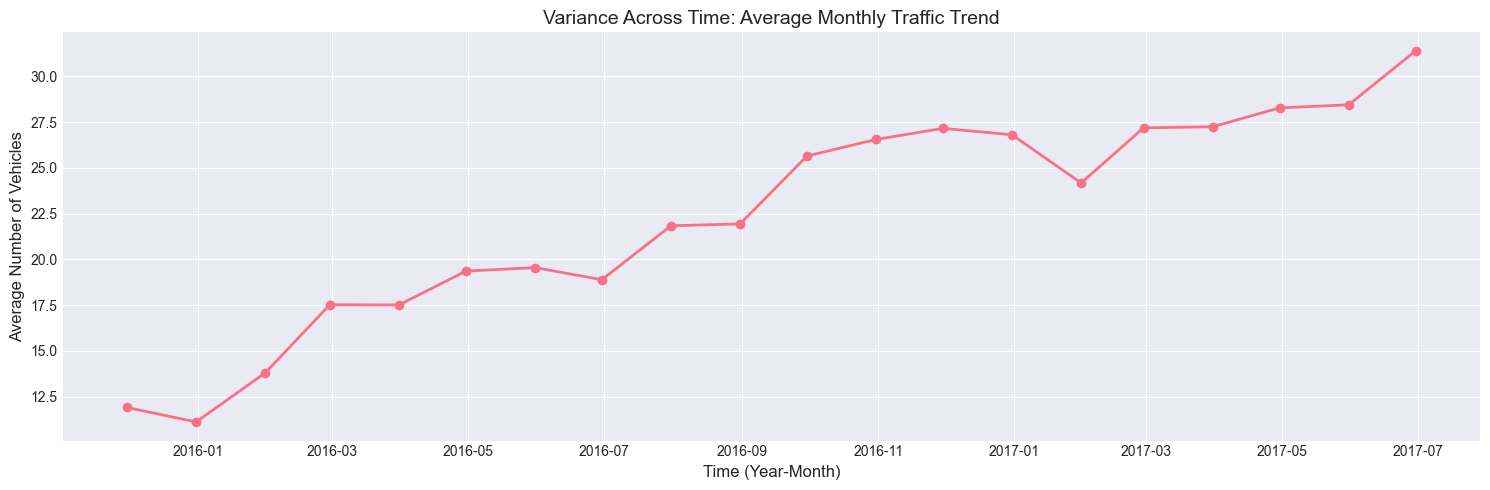

In [2]:
# Variance over time & Trend Discovery

plt.figure(figsize=(15, 5))

# Plotting variance across time (Monthly average traffic)
monthly_traffic = df.set_index('DateTime').resample('M')['Vehicles'].mean()

plt.plot(monthly_traffic.index, monthly_traffic.values, marker='o', linestyle='-', linewidth=2)
plt.title('Variance Across Time: Average Monthly Traffic Trend', fontsize=14)
plt.xlabel('Time (Year-Month)', fontsize=12)
plt.ylabel('Average Number of Vehicles', fontsize=12)
plt.tight_layout()
plt.show()

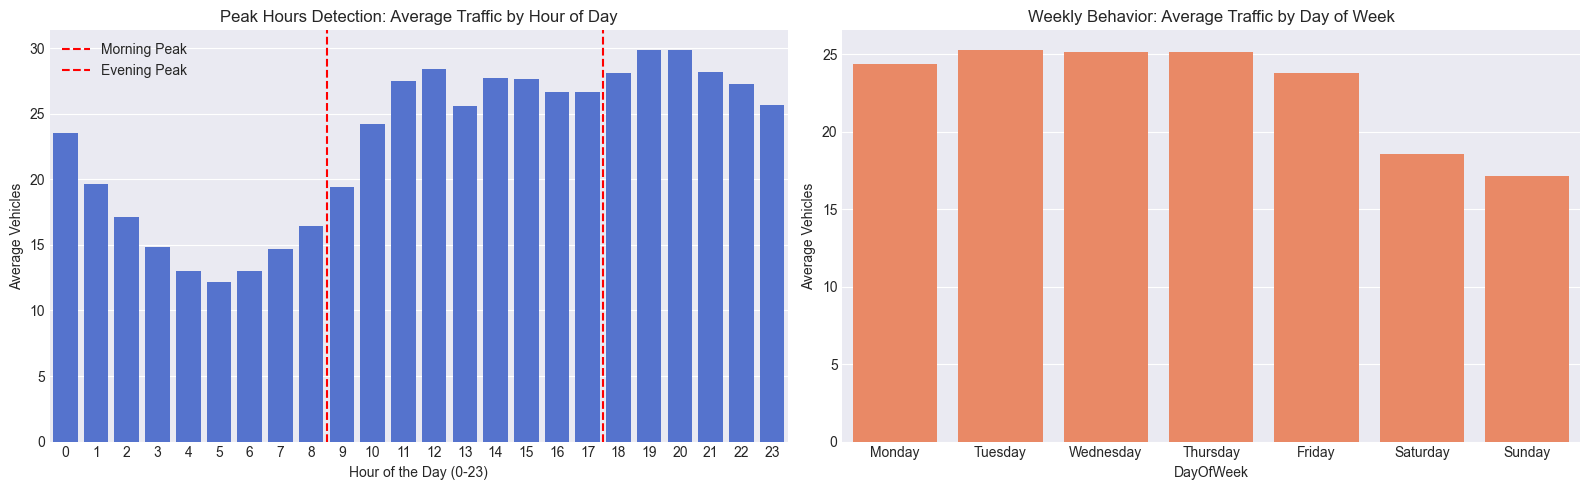

In [3]:
# Peak Hours & Weekly Behavior

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Peak Hours Detection
hourly_avg = df.groupby('Hour')['Vehicles'].mean()
sns.barplot(x=hourly_avg.index, y=hourly_avg.values, ax=axes[0], color='royalblue')
axes[0].set_title('Peak Hours Detection: Average Traffic by Hour of Day')
axes[0].set_xlabel('Hour of the Day (0-23)')
axes[0].set_ylabel('Average Vehicles')
axes[0].axvline(x=8.5, color='red', linestyle='--', label='Morning Peak')
axes[0].axvline(x=17.5, color='red', linestyle='--', label='Evening Peak')
axes[0].legend()

# 2. Weekly Traffic Behavior
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_avg = df.groupby('DayOfWeek')['Vehicles'].mean()
sns.barplot(x=weekly_avg.index, y=weekly_avg.values, ax=axes[1], color='coral')
axes[1].set_title('Weekly Behavior: Average Traffic by Day of Week')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days)
axes[1].set_ylabel('Average Vehicles')

plt.tight_layout()
plt.show()

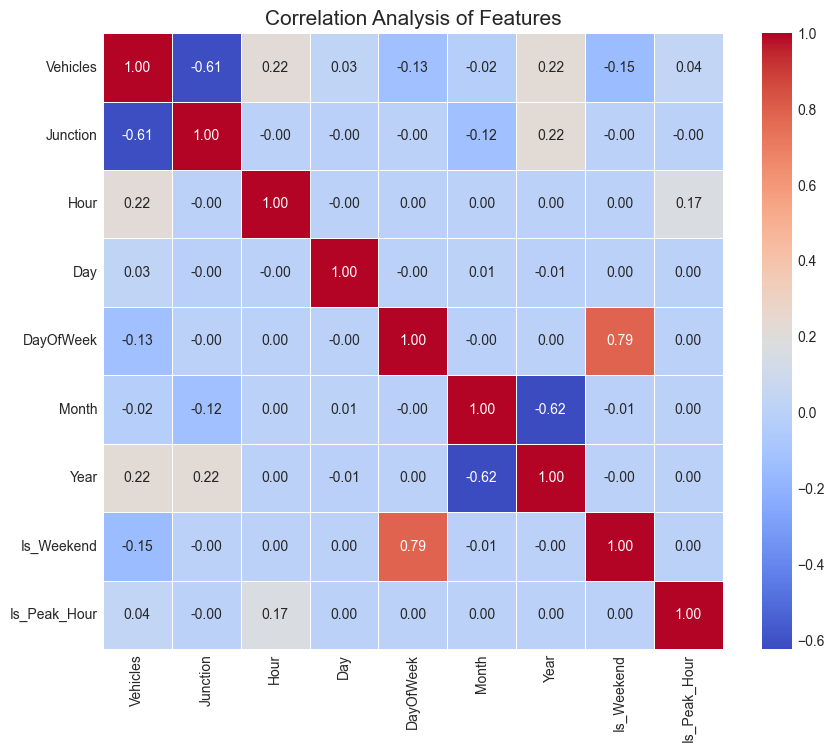

In [4]:
# Correlation Analysis

plt.figure(figsize=(10, 8))

# Select only numerical features for correlation matrix
num_features = ['Vehicles', 'Junction', 'Hour', 'Day', 'DayOfWeek', 'Month', 'Year', 'Is_Weekend', 'Is_Peak_Hour']
corr_matrix = df[num_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Analysis of Features', fontsize=15)
plt.show()

## 2. Implementing Linear Regression From Scratch
To understand the mathematical foundation of ML, I am implementing Linear Regression using **Gradient Descent** in its pure matrix formulation.

**Hypothesis Function (Matrix Form):** $Y_{pred} = X \cdot W$  

**Cost Function (MSE):** $J(W) = \frac{1}{2m} \sum_{i=1}^{m} (Y_{pred}^{(i)} - Y^{(i)})^2$  

**Gradient Calculation:** $dW = \frac{1}{m} X^T (Y_{pred} - Y)$  

**Gradient Descent Update Rule:** $W_{new} = W_{old} - \alpha \cdot dW$

In [5]:
class CustomLinearRegression:
    def __init__(self, alpha=0.01, iterations=1000):
        self.alpha = alpha       # Changed from learning_rate to alpha
        self.iterations = iterations
        self.W = None            # Changed from weights to W
        self.B = None            # Changed from bias to B
        self.cost_history = []
        
    def fit(self, X, Y):         # Changed from y to Y
        # m = number of samples, n = number of features
        m, n = X.shape
        
        # Initialize weights and bias to zeros
        self.W = np.zeros(n)
        self.B = 0
        
        # Gradient Descent Optimization
        for i in range(self.iterations):
            # 1. Predictions
            Y_pred = np.dot(X, self.W) + self.B    
            
            # 2. Calculate Gradients
            dW = (1 / m) * np.dot(X.T, (Y_pred - Y)) 
            dB = (1 / m) * np.sum(Y_pred - Y)        
            
            # 3. Update Weights & Bias
            self.W -= self.alpha * dW
            self.B -= self.alpha * dB
            
            # Calculate cost (MSE) 
            cost = (1 / (2 * m)) * np.sum((Y_pred - Y) ** 2)
            self.cost_history.append(cost)
            
    def predict(self, X):
        return np.dot(X, self.W) + self.B

In [6]:
# Data Prep & Training

# 1. Select features based on correlation and logic
features = ['Junction', 'Hour', 'DayOfWeek', 'Month', 'Year', 'Is_Weekend', 'Is_Peak_Hour']
X = df[features].values
y = df['Vehicles'].values

# 2. Time-Series Train-Test Split (DO NOT SHUFFLE!)
# We train on past data to predict future data
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 3. Standardization (Crucial for Gradient Descent to converge)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Custom Model 
custom_model = CustomLinearRegression(alpha=0.1, iterations=500)
custom_model.fit(X_train_scaled, y_train)
y_pred_custom = custom_model.predict(X_test_scaled)

# 5. Train Sklearn Baseline Model
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_scaled, y_train)
y_pred_sklearn = sklearn_model.predict(X_test_scaled)

print("Models Trained Successfully!")

Models Trained Successfully!


--- Custom Linear Regression (From Scratch) ---
RMSE: 9.1836
R2 Score: 0.1511

--- Scikit-Learn Baseline ---
RMSE: 9.1836
R2 Score: 0.1511



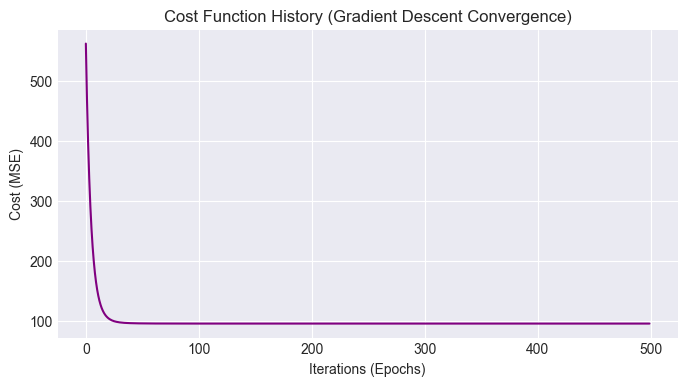

Bias-Variance Note: Because Linear Regression is a simple, high-bias model, it is unlikely to overfit (low variance). However, it struggles to capture the complex non-linear patterns in traffic data, which is why Riddhi, Utkarsha, and Akshaya will be building non-linear and ensemble models next!


In [7]:
# Evaluation & Bias-Variance Tradeoff

# Compare metrics
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}\n")

evaluate(y_test, y_pred_custom, "Custom Linear Regression (From Scratch)")
evaluate(y_test, y_pred_sklearn, "Scikit-Learn Baseline")

# --- Bias-Variance Understanding (Learning Curve) ---
# Plotting the loss curve of our custom model to prove it converged correctly
plt.figure(figsize=(8, 4))
plt.plot(range(custom_model.iterations), custom_model.cost_history, color='purple')
plt.title('Cost Function History (Gradient Descent Convergence)')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Cost (MSE)')
plt.show()

print("Bias-Variance Note: Because Linear Regression is a simple, high-bias model, it is unlikely to overfit (low variance). However, it struggles to capture the complex non-linear patterns in traffic data, which is why Riddhi, Utkarsha, and Akshaya will be building non-linear and ensemble models next!")